I wanted to experiment with networks within the map of Ridgewood I've been working on and to play around with mapping routes that prioritized going past the buildings with cornices that I have highlighted in my geojson. I went through a few iterations of finding these routes—a lot of the code variations were super comutationally heavy. I cut down the nodes to those close to the buildings I have highlighted, and experimented with routes between nodes that were farthest apart and then randomly generated... but not too close together (minimum of around 7 blocks) with edges weighted to favor areas with buildings with cornices. It was interesting to play around with trying to create a *longer* route, counter to so much of the mapping I use daily through City Mapper or Google maps. Along these lines, I had to be intentional about ensuring the code would generate "strolls" as opposed to shortest routes. As would be the case in many other neighborhoods in NYC, the routes I plotted emphasize the (mostly) uniform street grid and series of lengths + right angles we navigate in contrast to the Euclidean distance. 

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Point, Polygon
import pandas as pd
import requests
import networkx as nx
import osmnx as ox
import h3
import libpysal as lps

In [2]:
buildings = gpd.read_file("filtered_within_boundary.geojson")

In [12]:
print(buildings.columns)
print(buildings.head())

Index(['Borough', 'Block', 'Lot', 'CD', 'BCT2020', 'BCTCB2020', 'CT2010',
       'CB2010', 'SchoolDist', 'Council', 'ZipCode', 'FireComp', 'PolicePrct',
       'HealthCent', 'HealthArea', 'Sanitboro', 'SanitDistr', 'SanitSub',
       'Address', 'ZoneDist1', 'ZoneDist2', 'ZoneDist3', 'ZoneDist4',
       'Overlay1', 'Overlay2', 'SPDist1', 'SPDist2', 'SPDist3', 'LtdHeight',
       'SplitZone', 'BldgClass', 'LandUse', 'Easements', 'OwnerType',
       'OwnerName', 'LotArea', 'BldgArea', 'ComArea', 'ResArea', 'OfficeArea',
       'RetailArea', 'GarageArea', 'StrgeArea', 'FactryArea', 'OtherArea',
       'AreaSource', 'NumBldgs', 'NumFloors', 'UnitsRes', 'UnitsTotal',
       'LotFront', 'LotDepth', 'BldgFront', 'BldgDepth', 'Ext', 'ProxCode',
       'IrrLotCode', 'LotType', 'BsmtCode', 'AssessLand', 'AssessTot',
       'ExemptTot', 'YearBuilt', 'YearAlter1', 'YearAlter2', 'HistDist',
       'Landmark', 'BuiltFAR', 'ResidFAR', 'CommFAR', 'FacilFAR', 'BoroCode',
       'BBL', 'CondoNo', 'Tract2

In [3]:
bbox = buildings.total_bounds  # returns [minx, miny, maxx, maxy]

In [4]:
bbox

array([-73.91951165,  40.69394208, -73.89137379,  40.71287606])

In [5]:
point_network = ox.graph_from_address(
    "58-02 Catalpa Ave, Ridgewood, NY 11385",
    dist=1500,
    network_type="walk",
)

<Axes: >

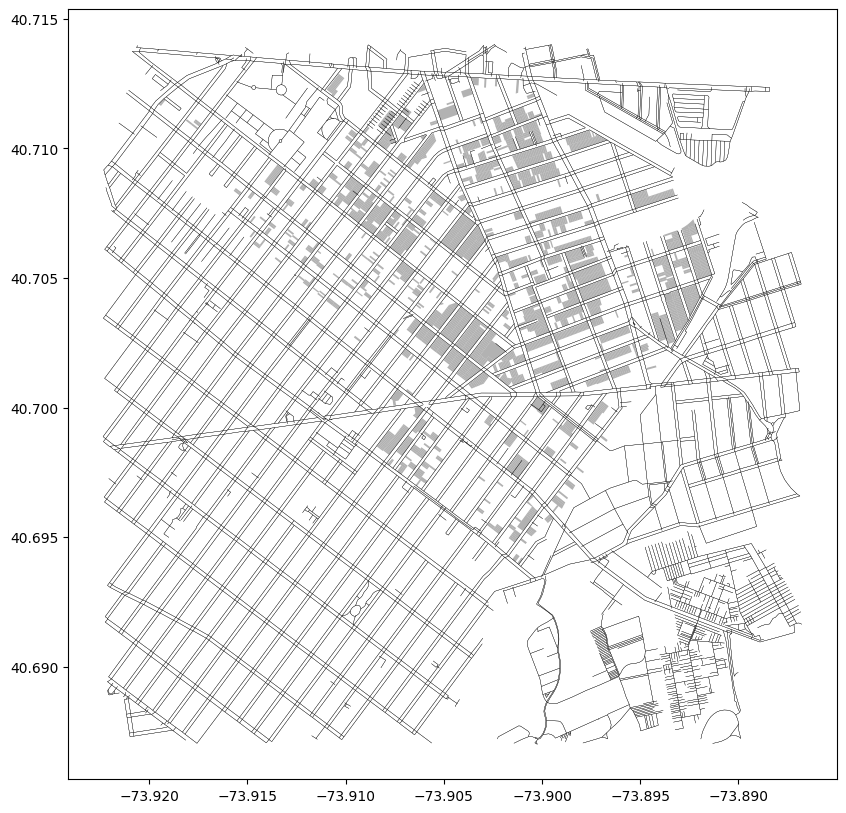

In [6]:
ridgewood_nodes, ridgewood_edges = ox.graph_to_gdfs(point_network)

# 4. Plot the buildings and network together
ax = buildings.plot(figsize=(10, 10), color="gray", alpha=0.6)
ridgewood_edges.plot(ax=ax, color="black", linewidth=0.2)

<Axes: >

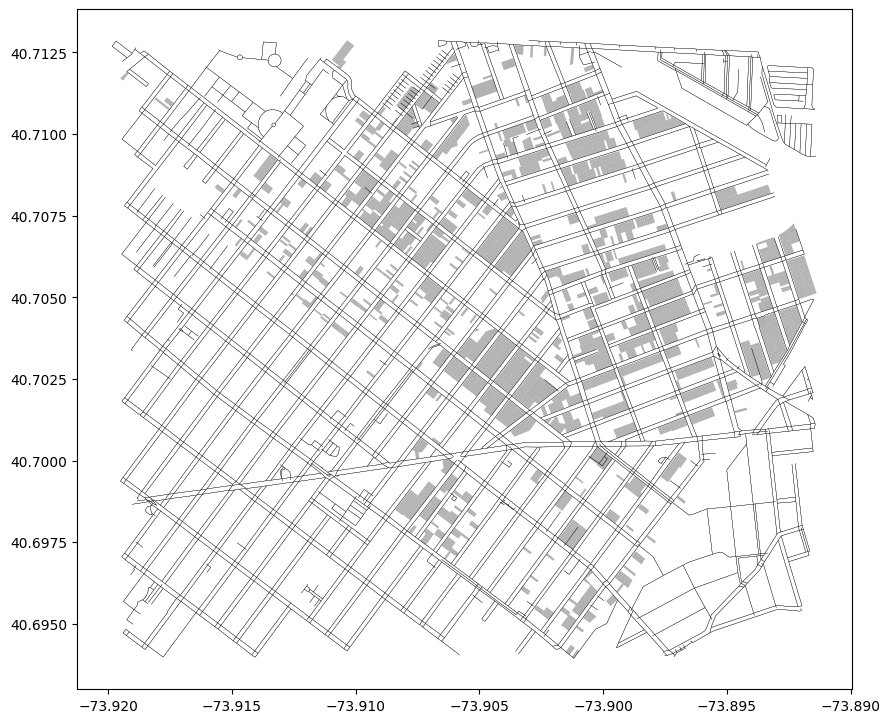

In [9]:
import geopandas as gpd
import osmnx as ox

# 1. Load buildings GeoJSON
buildings = gpd.read_file("filtered_within_boundary.geojson")

# 2. Ensure CRS is EPSG:4326 (WGS84 lat/lon)
buildings = buildings.to_crs(epsg=4326)

# 3. Get bounding box: [minx, miny, maxx, maxy]
bbox = buildings.total_bounds
bbox_tuple = (bbox[0], bbox[1], bbox[2], bbox[3])  # west, south, east, north

# 4. Get street network using OSMnx 2.x syntax
G = ox.graph_from_bbox(bbox=bbox_tuple, network_type="walk")

# 5. Convert network to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# 6. Plot buildings and network together
ax = buildings.plot(figsize=(10, 10), color="gray", alpha=0.6)
edges.plot(ax=ax, color="black", linewidth=0.2)

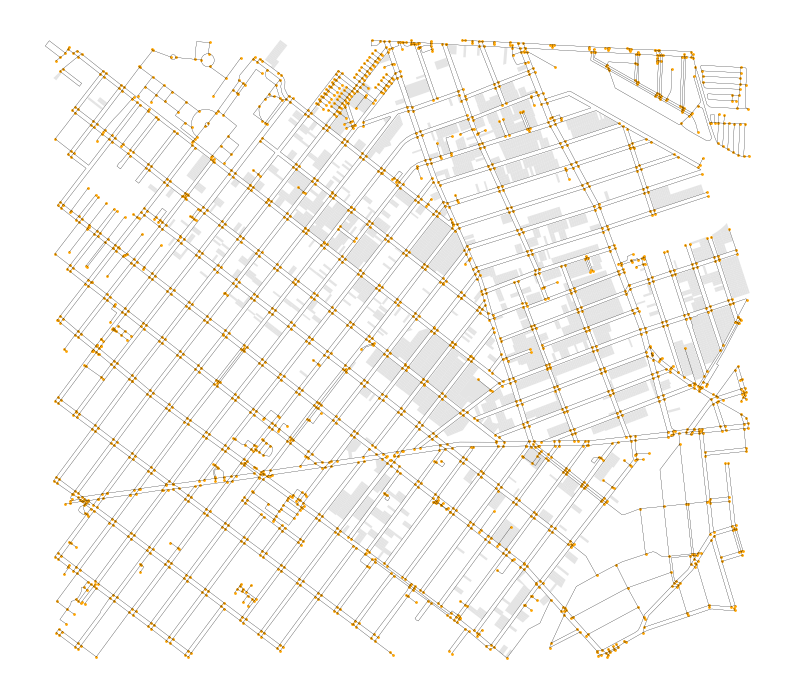

In [10]:
# Plot buildings first
ax = buildings.plot(figsize=(10, 10), color="lightgray", alpha=0.6)

# Then edges and nodes on top
edges.plot(ax=ax, color="black", linewidth=0.1)
nodes.plot(ax=ax, color="orange", markersize=1).set_axis_off()

In [11]:
# Example: Convert both to UTM (automatic for your region)
utm_crs = buildings.estimate_utm_crs()
buildings_proj = buildings.to_crs(utm_crs)
nodes_proj = nodes.to_crs(utm_crs)

/var/folders/w9/wqjyy9552z99wh2hxtn_2nbw0000gn/T/ipykernel_38974/108025042.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  building_centroids["geometry"] = building_centroids.centroid


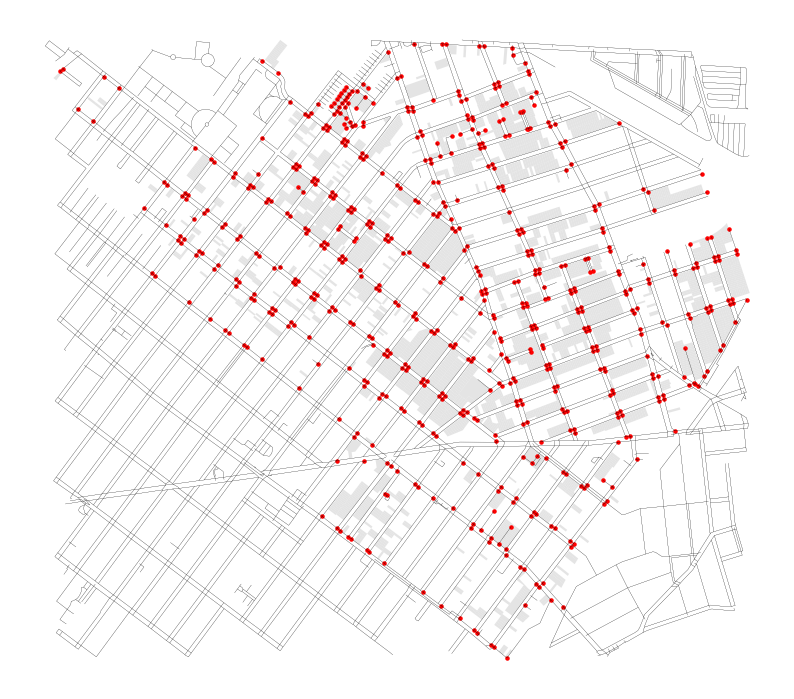

In [27]:
import geopandas as gpd
import osmnx as ox

# 1. Load buildings GeoJSON
buildings = gpd.read_file("filtered_within_boundary.geojson").to_crs(epsg=4326)

# 2. Get bounding box
bbox = buildings.total_bounds
bbox_tuple = (bbox[0], bbox[1], bbox[2], bbox[3])  # west, south, east, north

# 3. Get street network
G = ox.graph_from_bbox(bbox=bbox_tuple, network_type="walk")

# 4. Convert network to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G)

# 5. Get building centroids
building_centroids = buildings.copy()
building_centroids["geometry"] = building_centroids.centroid

# 6. Find nearest street edge for each building
# edges' index is (u, v, key), we just want u and v
nearest_edges = ox.distance.nearest_edges(
    G, X=building_centroids.geometry.x, Y=building_centroids.geometry.y
)

# 7. Extract the node IDs from the nearest edges
node_ids = set()
for u, v, _ in nearest_edges:
    node_ids.add(u)
    node_ids.add(v)

# 8. Filter nodes to only those in node_ids
nodes_filtered = nodes.loc[nodes.index.isin(node_ids)]

# 9. Plot
ax = buildings.plot(figsize=(10, 10), color="lightgray", alpha=0.6)
edges.plot(ax=ax, color="black", linewidth=0.1)
nodes_filtered.plot(ax=ax, color="red", markersize=5).set_axis_off()

/var/folders/w9/wqjyy9552z99wh2hxtn_2nbw0000gn/T/ipykernel_38974/353844685.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = buildings.unary_union.convex_hull


Selected farthest nodes: 9225198422, 9744131388, distance 2371.72 meters


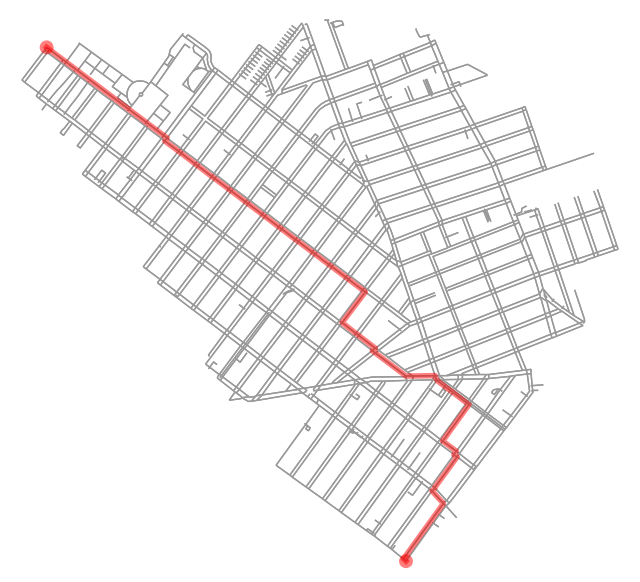

In [38]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import itertools

# 1. Load buildings GeoJSON
buildings = gpd.read_file("filtered_within_boundary.geojson")

# 2. Create convex hull polygon around buildings
convex_hull = buildings.unary_union.convex_hull

# 3. Download walk network clipped to convex hull
G = ox.graph_from_polygon(convex_hull, network_type="walk")

# 4. Project graph to metric CRS
G_proj = ox.project_graph(G)

# 5. Convert graph to GeoDataFrames
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

# 6. Reproject buildings to match graph CRS
buildings_proj = buildings.to_crs(nodes_proj.crs)

# 7. Buffer edges (e.g., 10m)
edges_buffered = edges_proj.copy()
edges_buffered["geometry"] = edges_buffered.geometry.buffer(10)

# Drop existing 'index_right' to avoid conflict
if "index_right" in buildings_proj.columns:
    buildings_proj = buildings_proj.drop(columns=["index_right"])

# 8. Spatial join: count buildings intersecting each buffered edge
joined = gpd.sjoin(edges_buffered, buildings_proj, how="left", predicate="intersects")
building_counts = joined.groupby(joined.index).size()

# 9. Assign building counts to edges (fill missing with zero)
edges_proj["building_count"] = edges_proj.index.map(building_counts).fillna(0)

# 10. Define edge weights so edges near more buildings have LOWER cost
max_count = edges_proj["building_count"].max()
edges_proj["weight"] = (max_count + 1) - edges_proj["building_count"]

# 11. Update graph edges with new weights
for u, v, k, data in G_proj.edges(keys=True, data=True):
    data["weight"] = edges_proj.loc[(u, v, k), "weight"]

# 12. Find farthest apart nodes (Euclidean distance)
max_dist = 0
start_node = None
end_node = None
for n1, n2 in itertools.combinations(nodes_proj.index, 2):
    dist = nodes_proj.loc[n1].geometry.distance(nodes_proj.loc[n2].geometry)
    if dist > max_dist:
        max_dist = dist
        start_node, end_node = n1, n2

print(
    f"Selected farthest nodes: {start_node}, {end_node}, distance {max_dist:.2f} meters"
)

# 13. Compute shortest path using custom weights
path_nodes = nx.shortest_path(
    G_proj, source=start_node, target=end_node, weight="weight"
)

# 14. Plot the route
fig, ax = ox.plot_graph_routes(
    G_proj,
    [path_nodes],
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
)

/var/folders/w9/wqjyy9552z99wh2hxtn_2nbw0000gn/T/ipykernel_41527/4103122685.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = buildings.unary_union.convex_hull


Random start node: 9762206660
Random end node: 9762206687


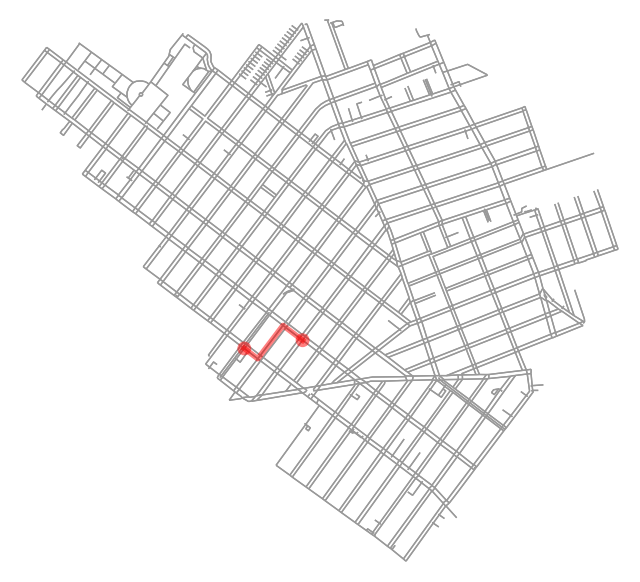

In [2]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import itertools

# 1. Load buildings GeoJSON
buildings = gpd.read_file("filtered_within_boundary.geojson")

# 2. Create convex hull polygon around buildings
convex_hull = buildings.unary_union.convex_hull

# 3. Download walk network clipped to convex hull
G = ox.graph_from_polygon(convex_hull, network_type="walk")

# 4. Project graph to metric CRS
G_proj = ox.project_graph(G)

# 5. Convert graph to GeoDataFrames
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

# 6. Reproject buildings to match graph CRS
buildings_proj = buildings.to_crs(nodes_proj.crs)

# 7. Buffer edges (e.g., 10m)
edges_buffered = edges_proj.copy()
edges_buffered["geometry"] = edges_buffered.geometry.buffer(10)

# Drop existing 'index_right' to avoid conflict
if "index_right" in buildings_proj.columns:
    buildings_proj = buildings_proj.drop(columns=["index_right"])

# 8. Spatial join: count buildings intersecting each buffered edge
joined = gpd.sjoin(edges_buffered, buildings_proj, how="left", predicate="intersects")
building_counts = joined.groupby(joined.index).size()

# 9. Assign building counts to edges (fill missing with zero)
edges_proj["building_count"] = edges_proj.index.map(building_counts).fillna(0)

# 10. Define edge weights so edges near more buildings have LOWER cost
max_count = edges_proj["building_count"].max()
edges_proj["weight"] = (max_count + 1) - edges_proj["building_count"]

# 11. Update graph edges with new weights
for u, v, k, data in G_proj.edges(keys=True, data=True):
    data["weight"] = edges_proj.loc[(u, v, k), "weight"]

# 12. Random points
import random

# Find nodes within 20m of buildings
nodes_near_buildings = nodes_proj[
    nodes_proj.geometry.apply(lambda p: buildings_proj.distance(p) < 20)
].index.tolist()

# Randomly pick start and end nodes from these nodes
start_node = random.choice(nodes_near_buildings)
end_node = random.choice(nodes_near_buildings)

print(f"Random start node: {start_node}")
print(f"Random end node: {end_node}")


# 13. Compute shortest path using custom weights
path_nodes = nx.shortest_path(
    G_proj, source=start_node, target=end_node, weight="weight"
)

# 14. Plot the route
fig, ax = ox.plot_graph_routes(
    G_proj,
    [path_nodes],
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
)

/var/folders/w9/wqjyy9552z99wh2hxtn_2nbw0000gn/T/ipykernel_38974/1129969699.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = buildings.unary_union.convex_hull


Selected start node 42881751 and end node 9762206845 with path length >= 560m


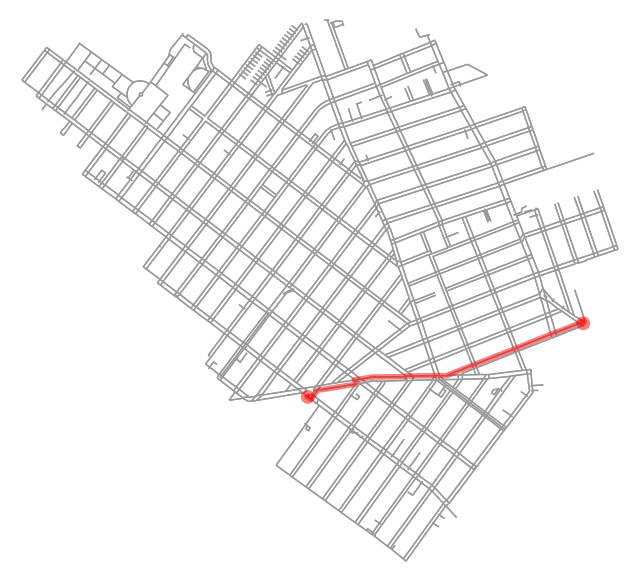

In [ ]:
import geopandas as gpd
import osmnx as ox
import networkx as nx
import itertools
import random

# 1. Load buildings GeoJSON
buildings = gpd.read_file("filtered_within_boundary.geojson")

# 2. Create convex hull polygon around buildings
convex_hull = buildings.unary_union.convex_hull

# 3. Download walk network clipped to convex hull
G = ox.graph_from_polygon(convex_hull, network_type="walk")

# 4. Project graph to metric CRS
G_proj = ox.project_graph(G)

# 5. Convert graph to GeoDataFrames
nodes_proj, edges_proj = ox.graph_to_gdfs(G_proj)

# 6. Reproject buildings to match graph CRS
buildings_proj = buildings.to_crs(nodes_proj.crs)

# 7. Buffer edges (e.g., 10m) to capture nearby buildings
edges_buffered = edges_proj.copy()
edges_buffered["geometry"] = edges_buffered.geometry.buffer(10)

# Drop any 'index_right' column if present to avoid conflicts
if "index_right" in buildings_proj.columns:
    buildings_proj = buildings_proj.drop(columns=["index_right"])

# 8. Spatial join: count how many buildings intersect each buffered edge
joined = gpd.sjoin(edges_buffered, buildings_proj, how="left", predicate="intersects")
building_counts = joined.groupby(joined.index).size()

# 9. Assign building counts to edges (fill missing with zero)
edges_proj["building_count"] = edges_proj.index.map(building_counts).fillna(0)

# 10. Define edge weights so edges near more buildings have LOWER cost
max_count = edges_proj["building_count"].max()
edges_proj["weight"] = (max_count + 1) - edges_proj["building_count"]

# 11. Update graph edges with new weights
for u, v, k, data in G_proj.edges(keys=True, data=True):
    data["weight"] = edges_proj.loc[(u, v, k), "weight"]

# 12. Find nodes within 20m of buildings
nodes_near_buildings = nodes_proj[
    nodes_proj.geometry.apply(lambda p: buildings_proj.distance(p) < 20)
].index.tolist()

# 13. Function to find random start/end nodes at least 7 blocks apart (~560m)
block_length = 80  # meters (adjust if needed)
min_distance = 7 * block_length  # 560 meters minimum


def find_random_nodes_far_apart(nodes, graph, min_dist, max_tries=1000):
    for _ in range(max_tries):
        start = random.choice(nodes)
        end = random.choice(nodes)
        if start == end:
            continue
        try:
            length = nx.shortest_path_length(graph, start, end, weight="length")
            if length >= min_dist:
                return start, end
        except nx.NetworkXNoPath:
            continue
    # fallback if none found
    return random.choice(nodes), random.choice(nodes)


start_node, end_node = find_random_nodes_far_apart(
    nodes_near_buildings, G_proj, min_distance
)

print(
    f"Selected start node {start_node} and end node {end_node} with path length >= {min_distance}m"
)

# 14. Compute shortest path using custom weights
path_nodes = nx.shortest_path(
    G_proj, source=start_node, target=end_node, weight="weight"
)

# 15. Plot the route and buildings together
fig, ax = ox.plot_graph_routes(
    G_proj,
    [path_nodes],
    route_color="red",
    route_linewidth=3,
    node_size=0,
    bgcolor="white",
)

# Plot buildings on top, with a transparent fill and edge color
buildings_proj.plot(ax=ax, facecolor="lightgray", edgecolor="black", alpha=0.6)

# Show the combined plot
import matplotlib.pyplot as plt

plt.show()